## Tutorial On using CEOS correctors remotely

## 1. Start servers

In [2]:
""" Run servers in DB mode
Steps to run the servers - see scripts/README_db_mode.md

Terminal 1:
TANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2

Terminal 2:
export TANGO_HOST=localhost:11000 
uv run scripts/2_register_devices.py 

Terminal 3:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.hardware.SCAN scan_instance

Terminal 4:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.hardware.CORRECTOR corrector_instance

Terminal 5:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.ThermoDigitalTwin microscope_twin_instance
"""


' Run servers in DB mode\nSteps to run the servers - see scripts/README_db_mode.md\n\nTerminal 1:\nTANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2\n\nTerminal 2:\nexport TANGO_HOST=localhost:11000 \nuv run scripts/2_register_devices.py \n\nTerminal 3:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.hardware.SCAN scan_instance\n\nTerminal 4:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.hardware.CORRECTOR corrector_instance\n\nTerminal 5:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.ThermoDigitalTwin microscope_twin_instance\n'

In [3]:
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [4]:
os.environ["TANGO_HOST"] = "localhost:11000"

In [5]:
# set timeouts
scan = tango.DeviceProxy("test/scan/1")
# mic_proxy = tango.DeviceProxy("test/microscope_twin/1")
mic_proxy = tango.DeviceProxy("test/microscope/1")
corrector_proxy = tango.DeviceProxy("test/corrector/1")

scan.set_timeout_millis(120_000)
mic_proxy.set_timeout_millis(120_000)
corrector_proxy.set_timeout_millis(120_000)

In [6]:
print('\n--- Microscope commands ---')
for cmd in mic_proxy.get_command_list():
    print(f'  {cmd}')

print('\n--- Microscope commands ---')
for cmd in corrector_proxy.get_command_list():
    print(f'  {cmd}')

print('\n--- Microscope commands ---')
for cmd in scan.get_command_list():
    print(f'  {cmd}')


--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  auto_focus
  blank_beam
  get_camera_image
  get_fov
  get_image_data_cached
  get_images
  get_scanned_image
  get_screen_current
  get_spectrum
  get_stage
  move_stage
  place_beam
  place_beam_list
  set_fov
  set_image_shift
  set_screen_current
  unblank_beam

--- Microscope commands ---
  Init
  State
  Status
  acquire_tableau
  correct_aberration
  get_aberrations_coeff_sim
  get_info
  measure_c1a1
  reconnect
  set_aberrations_coeff_sim

--- Microscope commands ---
  Activate
  Init
  State
  Status


In [7]:
## commands on the corrector
#   acquire_tableau
#   correct_aberration

## 2. Q. What abberations coefficient we can control using this script?
| Key | Order | Threshold | Scale | Unit |
|---|---|---:|---:|---|
| WD | 1st | 5e-3 | 1e3 | mm |
| C1 | 1st | 5e-9 | 1e9 | nm |
| A1 | 1st | 5e-9 | 1e9 | nm |
| B2 | 2nd | 50e-9 | 1e9 | nm |
| A2 | 2nd | 100e-9 | 1e9 | nm |
| C3 | 3rd | 1e-6 | 1e9 | nm |
| S3 | 3rd | 0.7e-6 | 1e9 | nm |
| A3 | 3rd | 1e-6 | 1e9 | nm |
| A4 | 4th | 10e-6 | 1e6 | µm |
| D4 | 4th | 4e-6 | 1e6 | µm |
| B4 | 4th | 10e-6 | 1e6 | µm |




## 3.  Examples to get aberrations values from the Microscope?
```python
ab_msg = corrector_proxy.acquire_tableau('Fast 18') # fast mode with tilt angle of 18 degreees
ab_msg = corrector_proxy.acquire_tableau('Standard 40')# standard mode with tilt angle of 40 degrees
ab_msg = corrector_proxy.acquire_tableau('Enhanced 40') # enhanced mode with tilt angle of 40 degrees
```

### Q. What fast, standard and enhanced mean?
- see the markdown cell below next code cell


In [11]:
# ab_msg = corrector_proxy.acquire_tableau('Fast 18')
# ab_msg = corrector_proxy.acquire_tableau('Standard 40')
ab_msg = corrector_proxy.acquire_tableau('Enhanced 40')
ab = json.loads(ab_msg)['result']['aberrations']
ab


{'A1': [-2.3483658318464037e-09, -1.1431333734657602e-10],
 'A2': [1.0384512890066242e-07, -7.064585031560053e-08],
 'C3': [1.2439637780399895e-06, 0.0],
 'C1': [6.64335964165214e-10, 0.0],
 'A4': [-2.0650884977695316e-06, -5.00494600806881e-07],
 'A3': [3.0238606467699374e-07, 3.101133027854638e-07],
 'A5': [3.950082560261085e-05, -2.7618042896009528e-05],
 'B2': [8.649314322765446e-09, 7.079136965404951e-09],
 'B4': [-1.3783232835502328e-07, -4.488838960499751e-06],
 'S3': [6.735608283361079e-07, 3.87930653924832e-08],
 'C5': [-0.0005997070839743189, 0.0],
 'D4': [-2.2512869668634708e-06, 9.767342822949656e-06],
 'WD': [0.00020124600949855486, -0.00015074416076996753]}

### notice abberations values for `Fast` run:
`
{'A1': [-4.459424477466636e-09, -8.17305624076105e-09],
 'A2': [6.334538586081132e-08, -1.0934314108610836e-08],
 'B2': [-4.971580068015865e-09, -1.0376221478431063e-08],
 'C1': [-1.6887036863357402e-08, 0.0],
 'WD': [-5.957208731043846e-05, -0.00011726381291000269]}
`
### notice abberations values for `Standard` run:
`
{'A1': [-2.5236378717944302e-09, -6.025717398601092e-10],
 'A2': [7.995235197378055e-08, -1.7246511161807312e-07],
 'C3': [-6.356002737012199e-07, 0.0],
 'C1': [1.3175133673068724e-09, 0.0],
 'A4': [-4.325904218752108e-06, -1.3723607183212023e-06],
 'A3': [3.435707450013314e-07, 1.825949250206582e-07],
 'B2': [8.89773469058357e-09, -1.0118467535717126e-08],
 'S3': [7.599830090519546e-07, 1.7411507459140872e-08],
 'WD': [0.0002772648075369717, -0.0001823856850940716]}
`
### notice abberations values for `Enhanced` run:
`
{'A1': [-2.3483658318464037e-09, -1.1431333734657602e-10],
 'A2': [1.0384512890066242e-07, -7.064585031560053e-08],
 'C3': [1.2439637780399895e-06, 0.0],
 'C1': [6.64335964165214e-10, 0.0],
 'A4': [-2.0650884977695316e-06, -5.00494600806881e-07],
 'A3': [3.0238606467699374e-07, 3.101133027854638e-07],
 'A5': [3.950082560261085e-05, -2.7618042896009528e-05],
 'B2': [8.649314322765446e-09, 7.079136965404951e-09],
 'B4': [-1.3783232835502328e-07, -4.488838960499751e-06],
 'S3': [6.735608283361079e-07, 3.87930653924832e-08],
 'C5': [-0.0005997070839743189, 0.0],
 'D4': [-2.2512869668634708e-06, 9.767342822949656e-06],
 'WD': [0.00020124600949855486, -0.00015074416076996753]}
`

## 4. Lets get an image

In [20]:
# take image on microscope
## helper funcs.
def get_image(dwell=10e-6, imsize=512):
    scan.dwell_time = dwell
    scan.imsize  = imsize

    json_meta, raw_bytes = mic_proxy.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

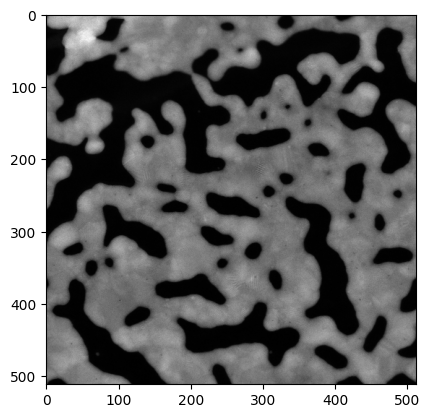

In [22]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='gray')

## 5. Examples to set the values in corrector?:
```python
# Scalar examples
corrector_proxy.correct_aberration("WD 0.002")
corrector_proxy.correct_aberration("C1 3e-9")
corrector_proxy.correct_aberration("C3 5e-7")

# Vector examples
corrector_proxy.correct_aberration("A1 2e-9 -1e-9")
corrector_proxy.correct_aberration("B2 20e-9 10e-9")
corrector_proxy.correct_aberration("A4 2e-6 -3e-6")
```

In [25]:
# set abberations - 100 nm
corrector_proxy.correct_aberration("C1 +150e-9")

'{"jsonrpc": "2.0", "result": null, "id": 19}'

## 6. observed_change ≈ -0.75 × commanded_change


### System Behavior (Empirical Observation)

We are controlling a parameter (e.g., defocus / lens setting) incrementally, and observing a measured value derived from the image.

### Sequential Response

Starting from an initial state (~ -70 nm), applying incremental commands:

| Command (nm) | Measured Value (nm) |
|---|---|
| +100 | -145 |
| -100 | -70 |
| +50  | -107 |
| -50  | -69 |
| +150 | -181 |
| -150 | -68 |

### Derived Behavior

Compute the change relative to previous state:

| Command Δ (nm) | Observed Δ (nm) |
|---|---|
| +100 | -75 |
| -100 | +75 |
| +50  | -37 |
| -50  | +38 |
| +150 | -112 |
| -150 | +113 |

### Key Insight

The system behaves approximately as:
observed_change ≈ -0.75 × commanded_change


## 7. Finally get image again after setting the aberrations parameter

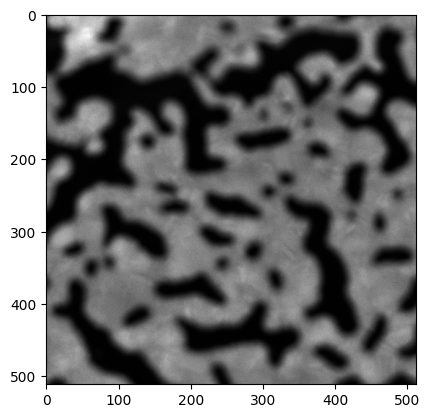

In [24]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='gray')

## 7 Q. How to change aberrations parametrs for A1x and A1y i.e astigmatism?

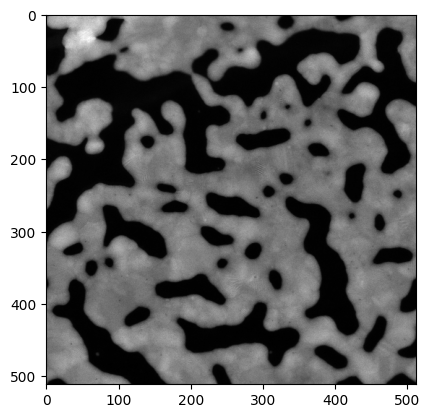

In [26]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='gray')

In [29]:
corrector_proxy.correct_aberration("A1 +200e-9 +200e-9")

'{"jsonrpc": "2.0", "result": null, "id": 21}'

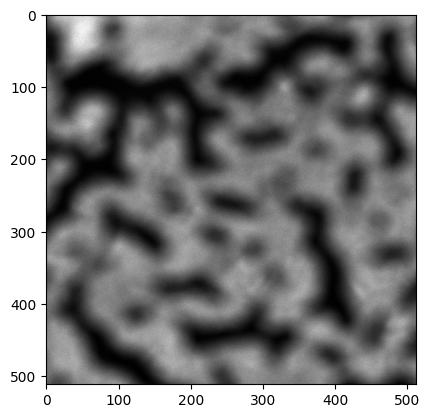

In [30]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='gray')

## 8. Conclusion
1. We queried the aberrations, acquired an image, then we changed defocus and finally queried the image again
2. We did the same for A1x and A1y i.e astigmatism